<a href="https://colab.research.google.com/github/iship-itb14/ishitp-itb14.github.io/blob/main/Data_Mining_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
!mkdir -p data
!cd data

!wget -r -np -nd --reject "index.html*" -e robots=off https://noaadata.apps.nsidc.org/NOAA/G02135/south/monthly/data/

--2026-03-05 21:34:33--  https://noaadata.apps.nsidc.org/NOAA/G02135/south/monthly/data/
Resolving noaadata.apps.nsidc.org (noaadata.apps.nsidc.org)... 128.138.135.43
Connecting to noaadata.apps.nsidc.org (noaadata.apps.nsidc.org)|128.138.135.43|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘index.html.tmp’

index.html.tmp          [ <=>                ]   1.66K  --.-KB/s    in 0s      

2026-03-05 21:34:33 (166 MB/s) - ‘index.html.tmp’ saved [1697]

Removing index.html.tmp since it should be rejected.

--2026-03-05 21:34:33--  https://noaadata.apps.nsidc.org/NOAA/G02135/south/monthly/data/S_01_extent_v4.0.csv
Reusing existing connection to noaadata.apps.nsidc.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2352 (2.3K) [application/octet-stream]
Saving to: ‘S_01_extent_v4.0.csv.3’

S_01_extent_v4.0.cs 100%[===================>]   2.30K  --.-KB/s    in 0s      

2026-03-05 21:34:33 (124 MB/s) - ‘S_01_extent_v

In [103]:
import pandas as pd
import glob

files = glob.glob("data/*.csv")

df_list = []

for file in files:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

df.head()

,year,mo,source_dataset,region,extent,area
0,1978,11,NSIDC-0051,S,15.90,11.69
1,1979,11,NSIDC-0051,S,15.34,11.32
2,1980,11,NSIDC-0051,S,16.13,11.84
3,1981,11,NSIDC-0051,S,16.11,12.07
4,1982,11,NSIDC-0051,S,15.54,11.27


In [104]:
df.head()

,year,mo,source_dataset,region,extent,area
0,1978,11,NSIDC-0051,S,15.90,11.69
1,1979,11,NSIDC-0051,S,15.34,11.32
2,1980,11,NSIDC-0051,S,16.13,11.84
3,1981,11,NSIDC-0051,S,16.11,12.07
4,1982,11,NSIDC-0051,S,15.54,11.27


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            568 non-null    int64  
 1    mo             568 non-null    int64  
 2   source_dataset  568 non-null    object 
 3    region         568 non-null    object 
 4    extent         568 non-null    float64
 5      area         568 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 26.8+ KB


In [106]:
df.describe()

,year,mo,extent,area
count,568.000000,568.000000,568.00000,568.000000
mean,2002.000000,6.500000,-23.77125,-26.541127
std,13.678083,3.468681,593.51464,593.341343
min,1978.000000,1.000000,-9999.00000,-9999.000000
25%,1990.000000,3.000000,5.71750,3.985000
50%,2002.000000,6.500000,11.85000,8.840000
75%,2014.000000,10.000000,16.67500,13.162500
max,2026.000000,12.000000,19.76000,15.750000


In [107]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['year', 'mo', 'source_dataset', 'region', 'extent', 'area'], dtype='object')

In [108]:
import numpy as np

df.replace(-9999, np.nan, inplace=True)
df.isnull().sum()

,0
year,0
mo,0
source_dataset,0
region,0
extent,2
area,2


In [109]:
df.dropna(inplace=True)

In [110]:
df.dtypes

,0
year,int64
mo,int64
source_dataset,object
region,object
extent,float64
area,float64


In [111]:
df.columns

Index(['year', 'mo', 'source_dataset', 'region', 'extent', 'area'], dtype='object')

In [112]:
df.rename(columns={'year':'Year','mo':'Month'}, inplace=True)

In [113]:
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
df.sort_values('Date', inplace=True)

In [114]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [115]:
df[['Year','Month']].duplicated().sum()

np.int64(0)

In [116]:
df.columns

Index(['Year', 'Month', 'source_dataset', 'region', 'extent', 'area', 'Date'], dtype='object')

In [117]:
df.rename(columns={'extent':'Extent', 'area':'Area'}, inplace=True)

In [118]:
# Summary statistics
df['Extent'].describe()
df['Extent'].var()
df['Extent'].skew()
df['Extent'].kurt()

# Correlation
df[['Extent','Area']].corr()

,Extent,Area
Extent,1.000000,0.995798
Area,0.995798,1.000000


In [119]:
# Rolling 12-month average
df['Rolling_12'] = df['Extent'].rolling(window=12).mean()

# Anomaly
mean_extent = df['Extent'].mean()
df['Anomaly'] = df['Extent'] - mean_extent

In [120]:
df['Extent'].var()
df['Extent'].skew()
df['Extent'].kurt()

np.float64(-1.4579558867016098)

In [121]:
Q1 = df['Extent'].quantile(0.25)
Q3 = df['Extent'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Extent'] < lower) | (df['Extent'] > upper)]
outliers.head()

,Year,Month,source_dataset,region,Extent,Area,Date,Rolling_12,Anomaly


In [122]:
df.to_csv("antarctic_sea_ice_cleaned.csv", index=False)

In [123]:
df.dtypes

,0
Year,int64
Month,int64
source_dataset,object
region,object
Extent,float64
Area,float64
Date,datetime64[ns]
Rolling_12,float64
Anomaly,float64


In [124]:
df['Log_Extent'] = np.log(df['Extent'])

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [126]:
scaler = StandardScaler()
df[['Extent_scaled']] = scaler.fit_transform(df[['Extent']])

In [127]:
df['Rolling_12'] = df['Extent'].rolling(window=12).mean()

In [128]:
mean_extent = df['Extent'].mean()
df['Anomaly'] = df['Extent'] - mean_extent

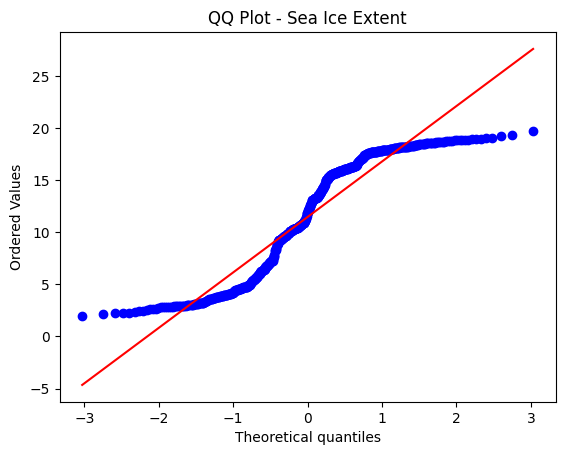

In [129]:
stats.probplot(df['Extent'], dist="norm", plot=plt)
plt.title("QQ Plot - Sea Ice Extent")
plt.show()

In [130]:
features = df[['Extent', 'Area']]
scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
principal = pca.fit_transform(scaled)

print(pca.explained_variance_ratio_)

[0.99789897 0.00210103]


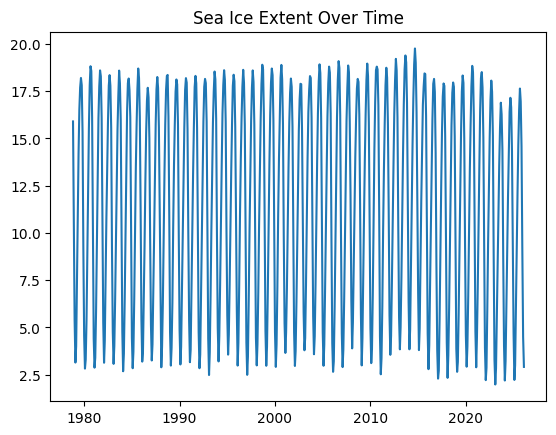

In [131]:
plt.figure()
plt.plot(df['Date'], df['Extent'])
plt.title("Sea Ice Extent Over Time")
plt.show()

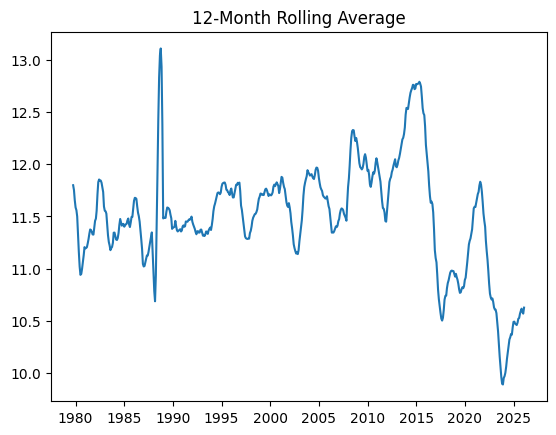

In [132]:
plt.figure()
plt.plot(df['Date'], df['Rolling_12'])
plt.title("12-Month Rolling Average")
plt.show()

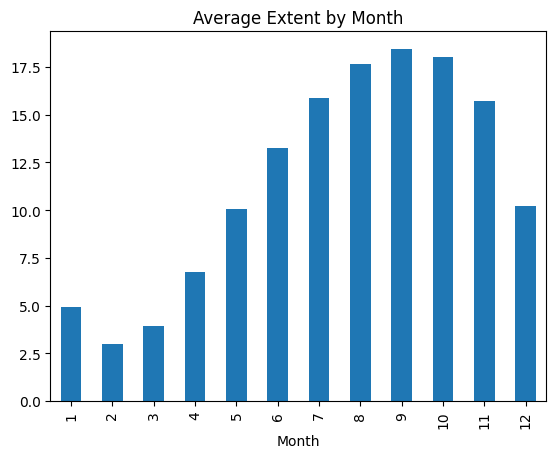

In [133]:
monthly_avg = df.groupby('Month')['Extent'].mean()

plt.figure()
monthly_avg.plot(kind='bar')
plt.title("Average Extent by Month")
plt.show()

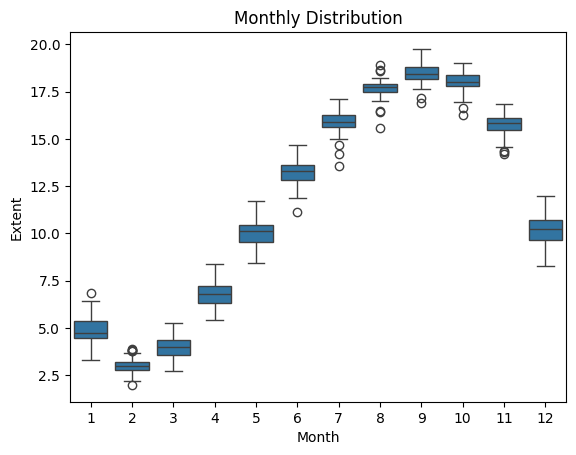

In [134]:
plt.figure()
sns.boxplot(x='Month', y='Extent', data=df)
plt.title("Monthly Distribution")
plt.show()

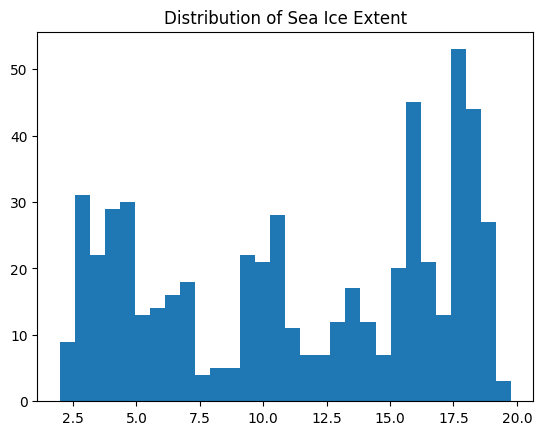

In [135]:
plt.figure()
plt.hist(df['Extent'], bins=30)
plt.title("Distribution of Sea Ice Extent")
plt.show()

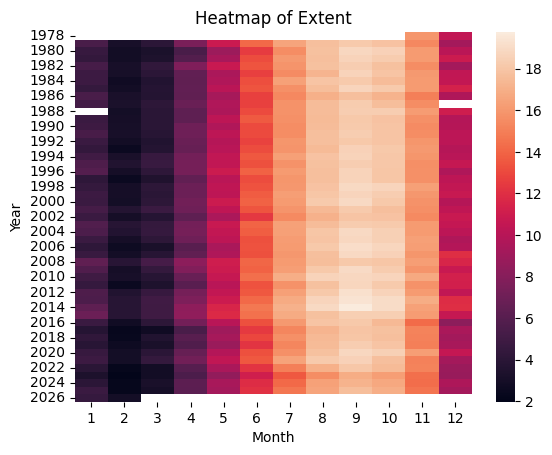

In [136]:
pivot = df.pivot_table(values='Extent', index='Year', columns='Month')

plt.figure()
sns.heatmap(pivot)
plt.title("Heatmap of Extent")
plt.show()

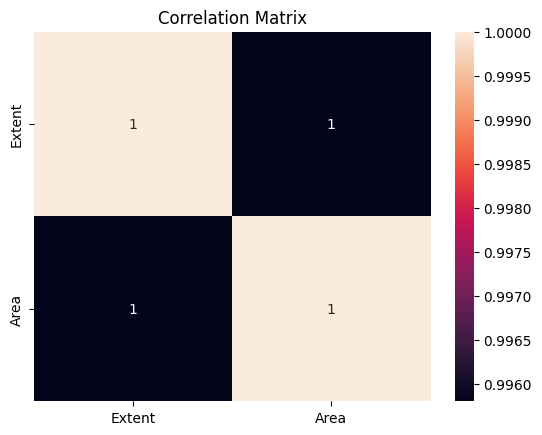

In [137]:
plt.figure()
sns.heatmap(df[['Extent','Area']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

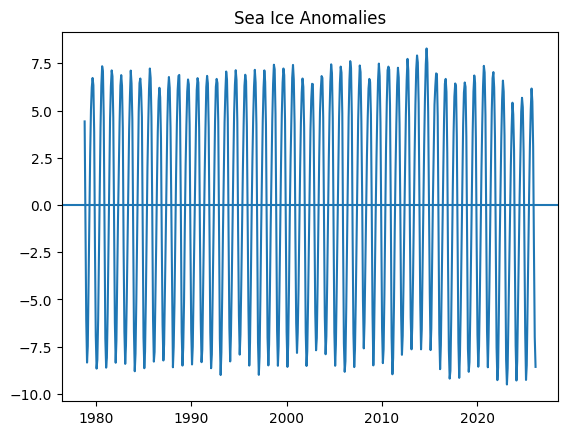

In [138]:
plt.figure()
plt.plot(df['Date'], df['Anomaly'])
plt.axhline(0)
plt.title("Sea Ice Anomalies")
plt.show()

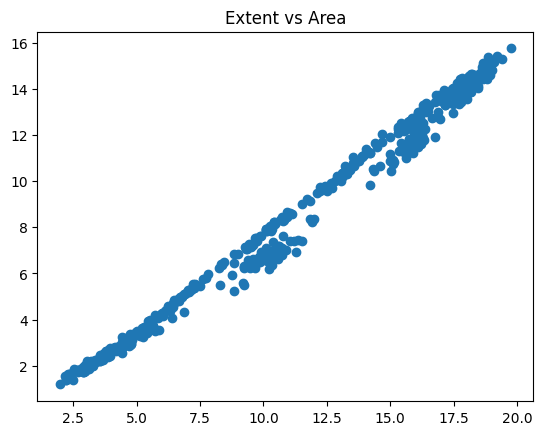

In [139]:
plt.figure()
plt.scatter(df['Extent'], df['Area'])
plt.title("Extent vs Area")
plt.show()

In [141]:

numeric_cols = df_clean.select_dtypes(include=['float64','int64']).columns

summary_stats = pd.DataFrame({
    'Count': df_clean[numeric_cols].count(),
    'Mean': df_clean[numeric_cols].mean(),
    'Median': df_clean[numeric_cols].median(),
    'Variance': df_clean[numeric_cols].var(),
    'Std Dev': df_clean[numeric_cols].std(),
    'Min': df_clean[numeric_cols].min(),
    'Max': df_clean[numeric_cols].max(),
    '25% Quantile': df_clean[numeric_cols].quantile(0.25),
    '50% Quantile': df_clean[numeric_cols].quantile(0.5),
    '75% Quantile': df_clean[numeric_cols].quantile(0.75),
    'Skewness': df_clean[numeric_cols].skew(),
    'Kurtosis': df_clean[numeric_cols].kurt()
})

summary_stats

,Count,Mean,Median,Variance,Std Dev,Min,Max,25% Quantile,50% Quantile,75% Quantile,Skewness,Kurtosis
Year,555,2002.511712,2003.000000,179.784610,13.408378,1979.000000,2026.000000,1991.000000,2003.000000,2014.000000,-0.007293,-1.194617
Month,555,6.506306,7.000000,11.968823,3.459599,1.000000,12.000000,3.500000,7.000000,10.000000,-0.003613,-1.223443
Extent,555,11.481369,11.930000,31.224924,5.587927,1.980000,19.760000,5.805000,11.930000,16.765000,-0.209296,-1.457838
Area,555,8.701676,9.150000,21.077574,4.591032,1.190000,15.750000,4.070000,9.150000,13.165000,-0.152316,-1.491886
Rolling_12,555,11.502742,11.505833,0.285051,0.533901,9.889167,13.110000,11.287083,11.505833,11.800000,-0.196234,0.927181
Anomaly,555,0.004461,0.453092,31.224924,5.587927,-9.496908,8.283092,-5.671908,0.453092,5.288092,-0.209296,-1.457838
Log_Extent,555,2.276020,2.479056,0.394793,0.628325,0.683097,2.983660,1.758701,2.479056,2.819293,-0.729003,-0.820835
Extent_scaled,555,0.000800,0.081219,1.003326,1.001662,-1.702365,1.484783,-1.016716,0.081219,0.947915,-0.209296,-1.457838


In [142]:
df_raw = df.copy()
df.replace(-9999, np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.rename(columns={'extent':'Extent','area':'Area'}, inplace=True)
df.to_csv("antarctic_sea_ice_cleaned.csv", index=False)
df_clean = df.copy()

In [143]:
missing_before = df_raw.replace(-9999, np.nan).isnull().sum().sum()
duplicates_before = df_raw.duplicated().sum()
missing_after = df_clean.isnull().sum().sum()
duplicates_after = df_clean.duplicated().sum()

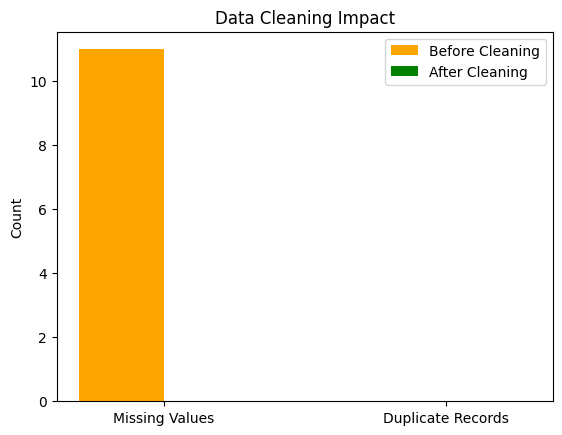

In [144]:
import matplotlib.pyplot as plt

missing_before = df_raw.isnull().sum().sum()
duplicates_before = df_raw.duplicated().sum()

missing_after = df_clean.isnull().sum().sum()
duplicates_after = df_clean.duplicated().sum()

labels = ['Missing Values', 'Duplicate Records']
before = [missing_before, duplicates_before]
after = [missing_after, duplicates_after]

x = range(len(labels))
plt.bar([i-0.15 for i in x], before, width=0.3, label='Before Cleaning', color='orange')
plt.bar([i+0.15 for i in x], after, width=0.3, label='After Cleaning', color='green')
plt.xticks(x, labels)
plt.ylabel("Count")
plt.title("Data Cleaning Impact")
plt.legend()
plt.show()

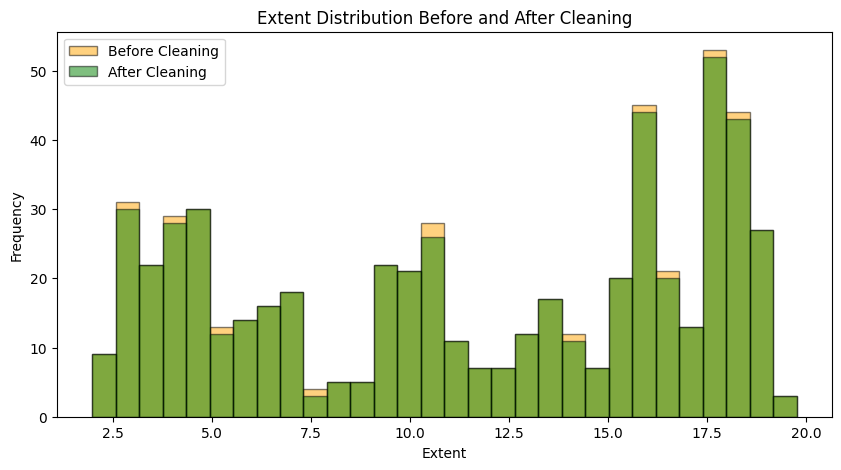

In [145]:
plt.figure(figsize=(10,5))
plt.hist(df_raw['Extent'].replace(-9999,np.nan).dropna(), bins=30, color='orange', edgecolor='black', alpha=0.5, label='Before Cleaning')
plt.hist(df_clean['Extent'], bins=30, color='green', edgecolor='black', alpha=0.5, label='After Cleaning')
plt.title("Extent Distribution Before and After Cleaning")
plt.xlabel("Extent")
plt.ylabel("Frequency")
plt.legend()
plt.show()